## UCI Credit-Fraud Benchmark (OCT + Resampling Baselines)

- **Vanilla** `M_o`: full training set, or cached test predictions when aligned (see flags below).
- **Ours (`M_c`)**: two-stage k-center curated training set.
- **Baselines**: `NearMiss-1`, `TomekLinks`, `ENN`, `NCL`, `SMOTE`.

`save_suffix` on disk is the slugified method name -> `oct_predictions_{slug}.csv`.

Undersamplers use `sample_indices_` + `train_pd` (same idea as `competing_methods.ipynb`). SMOTE adds synthetic rows only.

**Cached vanilla:** set path + flags; symmetric leaf deltas use it when test features + row count match.


In [ ]:
import os, re, sys, importlib
import numpy as np
import pandas as pd
from IPython.display import display

from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import NearMiss, TomekLinks, EditedNearestNeighbours, NeighbourhoodCleaningRule
from sklearn.metrics import roc_auc_score, average_precision_score, confusion_matrix

repo_root = os.path.abspath(os.path.join(os.getcwd(), '..'))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)

import public.model_IAI
import utils_fraud
import kcenter_hyperparameter_search_global
import symmetric_excess_AUC

importlib.reload(public.model_IAI)
importlib.reload(utils_fraud)
importlib.reload(kcenter_hyperparameter_search_global)
importlib.reload(symmetric_excess_AUC)

from public.model_IAI import finetune_oct, evaluate_binary_oct, best_mcc_threshold
from utils_fraud import (
    prepare_dataset_for_kcenter,
    setup_feature_columns,
    create_train_test_split,
    precompute_case_control_distances,
)
from kcenter_hyperparameter_search_global import run_global_kcenter_matching, build_undersampled_dataset
from symmetric_excess_AUC import symmetric_leaf_evaluation_oct

# -----------------------------------------------------------------------------
# CONFIG
# -----------------------------------------------------------------------------
TRAIN_TEST_SEED = 123
TARGET_COL = 'target'
RESULTS_DIR = './uci_competing_methods_results'
os.makedirs(RESULTS_DIR, exist_ok=True)

OCT_DEPTHS = [7]
OCT_MINBUCKETS = [25, 50, 100]
OCT_CPS = [1e-5, 1e-4, 1e-3, 1e-2]

# Cached vanilla OCT test predictions (optional skip training for M_o + table AUC/PR from cache)
VANILLA_PREDS_CANDIDATE = "/Users/cat2510/scratch/credit_fraud_main/uci_experiments_results/predictions/fraud_vanilla_oct_predictions.csv"
USE_CACHED_VANILLA_FOR_LEAF_REF = True
# If True and cache aligns: skip Vanilla finetune. Vanilla MCC/Recall then use MCC threshold on **test** only
# (other methods use val-tuned thresholds from evaluate_binary_oct). Set False for fully val-aligned Vanilla.
SKIP_VANILLA_TRAIN_IF_CACHE_VALID = True

OURS_MATCHING_RATIO = 1
OURS_CASE_WEIGHTING = None
OURS_USE_ADAPTIVE_POOL = True
OURS_SEED_METHOD = "smart"


def _safe_slug(name: str) -> str:
    return re.sub(r'[^A-Za-z0-9_\-]+', '_', str(name))


def _verify_cached_vanilla_preds(csv_path: str, X_test_df: pd.DataFrame, feature_cols: list) -> bool:
    if not os.path.isfile(csv_path):
        print(f"[vanilla cache] File missing: {csv_path}")
        return False
    van = pd.read_csv(csv_path)
    required = {"predicted_proba", "leaf_assignment", *feature_cols}
    missing = required - set(van.columns)
    if missing:
        print(f"[vanilla cache] Missing columns: {missing}")
        return False
    if len(van) != len(X_test_df):
        print(f"[vanilla cache] Row count: csv={len(van):,} vs test={len(X_test_df):,}")
        return False
    A = X_test_df[feature_cols].to_numpy(dtype=np.float64)
    B = van[feature_cols].to_numpy(dtype=np.float64)
    if not np.allclose(A, B, rtol=1e-5, atol=1e-6, equal_nan=True):
        print("[vanilla cache] Feature matrix mismatch vs current test split (order or values).")
        return False
    print("[vanilla cache] OK - features and row count match this notebook's test set.")
    return True


def _metrics_from_cached_vanilla_csv(y_test_series: pd.Series, pred_tbl: pd.DataFrame) -> dict:
    y = np.asarray(y_test_series).astype(int)
    p = np.asarray(pred_tbl["predicted_proba"]).astype(float)
    auc = float(roc_auc_score(y, p))
    pr_auc = float(average_precision_score(y, p))
    mcc_pack = best_mcc_threshold(y, p)
    y_hat = mcc_pack["y_pred"]
    tn, fp, fn, tp = confusion_matrix(y, y_hat).ravel()
    recall_mcc = float(tp / (tp + fn)) if (tp + fn) else 0.0
    return {
        "auc": auc,
        "pr_auc": pr_auc,
        "best_mcc": float(mcc_pack["mcc"]),
        "recall_mcc": recall_mcc,
    }


def apply_sampler_return_train_features(
    name: str,
    sampler,
    train_pd: pd.DataFrame,
    X_train: pd.DataFrame,
    y_train: pd.Series,
    feature_cols: list,
    target_col: str,
    n_majority_train: int,
):
    X_np = np.asarray(X_train[feature_cols], dtype=np.float64)
    y_np = np.asarray(y_train).astype(int)

    print(f"\n--- Resampling: {name} ---")
    print(f"    Before: n={len(y_np):,}  maj={int((y_np == 0).sum()):,}  min={int((y_np == 1).sum()):,}")

    X_res, y_res = sampler.fit_resample(X_np, y_np)

    if isinstance(sampler, SMOTE):
        n_syn = int(len(y_res) - len(y_np))
        print(f"    SMOTE added {n_syn:,} synthetic minority rows (not in train_pd index).")
        X_out = pd.DataFrame(X_res, columns=feature_cols)
        y_out = pd.Series(y_res, name=target_col)
    else:
        idx = getattr(sampler, "sample_indices_", None)
        if idx is None:
            raise RuntimeError(f"{name}: expected sample_indices_ from undersampler")
        idx = np.asarray(idx, dtype=int)
        if X_res.shape[0] != idx.size:
            print(f"    WARN: len(X_res)={X_res.shape[0]} vs len(sample_indices_)={idx.size}")
        tr_sub = train_pd.iloc[idx].reset_index(drop=True)
        if not np.array_equal(tr_sub[target_col].to_numpy(), y_res):
            raise RuntimeError(f"{name}: train_pd.iloc[sample_indices_] labels != y_res")
        X_out = tr_sub[feature_cols]
        y_out = tr_sub[target_col]
        print(f"    sample_indices_: {idx.size:,} rows, {len(np.unique(idx)):,} unique")

    maj_after = int((y_out == 0).sum())
    min_after = int((y_out == 1).sum())
    keep_pct = 100.0 * maj_after / n_majority_train
    print(f"    After:  n={len(y_out):,}  maj={maj_after:,}  min={min_after:,}  (% maj retained: {keep_pct:.2f}%)")
    return X_out, y_out, keep_pct


def train_eval_finetuned_oct(method_name: str, X_tr, y_tr, majority_retained_pct: float) -> dict:
    save_slug = _safe_slug(method_name)
    method_dir = os.path.join(RESULTS_DIR, save_slug)
    os.makedirs(method_dir, exist_ok=True)

    model, best_params, _, preprocessor, feature_names = finetune_oct(
        X_train=X_tr,
        y_train=y_tr,
        X_val=X_val,
        y_val=y_val,
        categorical_cols=CAT_COLUMNS,
        numeric_cols=TRUE_NUM_COLUMNS,
        binary_cols=BIN_COLUMNS,
        depths=OCT_DEPTHS,
        minbuckets=OCT_MINBUCKETS,
        cps=OCT_CPS,
        random_seed=TRAIN_TEST_SEED,
        verbose=True,
    )
    metrics = evaluate_binary_oct(
        iai_model=model,
        X_test_df=X_test,
        y_test=y_test,
        preprocessor=preprocessor,
        feature_names=feature_names,
        results_dir=method_dir,
        save_suffix=save_slug,
        X_val_df=X_val,
        y_val=y_val,
    )
    pred_path = os.path.join(method_dir, "predictions", f"oct_predictions_{save_slug}.csv")
    return {
        "method": method_name,
        "majority_retained_pct": float(majority_retained_pct),
        "auc": float(metrics["auc"]),
        "pr_auc": float(metrics["pr_auc"]),
        "mcc": float(metrics["best_mcc"]),
        "recall": float(metrics["recall_mcc"]),
        "pred_path": pred_path,
        "best_params": best_params,
    }


if not os.path.exists('creditcard.csv'):
    raise FileNotFoundError('creditcard.csv not found in current working directory.')

df_raw = pd.read_csv('creditcard.csv')
X_raw = df_raw.drop(columns=['Class'])
y_raw = df_raw['Class']

df = prepare_dataset_for_kcenter(X_raw, y_raw, dataset_name='creditcard_fraud')
df, feature_cols, CAT_COLUMNS, TRUE_NUM_COLUMNS, BIN_COLUMNS = setup_feature_columns(
    df, target_col=TARGET_COL, drop_time=False, log1p_amount=False
)
train_pd, val_pd, test_pd = create_train_test_split(df, target_col=TARGET_COL, random_state=TRAIN_TEST_SEED)

X_train = train_pd[feature_cols].copy()
y_train = train_pd[TARGET_COL].copy()
X_val = val_pd[feature_cols].copy()
y_val = val_pd[TARGET_COL].copy()
X_test = test_pd[feature_cols].copy()
y_test = test_pd[TARGET_COL].copy()
n_majority_train = int((y_train == 0).sum())

rows = []
vanilla_mv_pred_path = None
cache_ok = USE_CACHED_VANILLA_FOR_LEAF_REF and _verify_cached_vanilla_preds(
    VANILLA_PREDS_CANDIDATE, X_test, feature_cols
)

if cache_ok and SKIP_VANILLA_TRAIN_IF_CACHE_VALID:
    print(
        "\n[INFO] Using cached Vanilla predictions - skipping Vanilla OCT training.\n"
        "       Vanilla MCC/Recall: MCC threshold chosen on **test** (others use val from evaluate_binary_oct).\n"
        "       Set SKIP_VANILLA_TRAIN_IF_CACHE_VALID=False to retrain Vanilla for val-aligned metrics."
    )
    van_tbl = pd.read_csv(VANILLA_PREDS_CANDIDATE)
    mcached = _metrics_from_cached_vanilla_csv(y_test, van_tbl)
    vanilla_mv_pred_path = os.path.abspath(VANILLA_PREDS_CANDIDATE)
    rows.append({
        "method": "Vanilla",
        "majority_retained_pct": 100.0,
        "auc": mcached["auc"],
        "pr_auc": mcached["pr_auc"],
        "mcc": mcached["best_mcc"],
        "recall": mcached["recall_mcc"],
        "pred_path": vanilla_mv_pred_path,
        "best_params": None,
    })
else:
    if cache_ok:
        print("[INFO] Cache valid but SKIP_VANILLA_TRAIN_IF_CACHE_VALID is False - training Vanilla.")
    rows.append(train_eval_finetuned_oct("Vanilla", X_train, y_train, 100.0))
    vanilla_mv_pred_path = rows[-1]["pred_path"]

print("\n=== Ours (M_c): two-stage k-center ===")
pn_h5_path, _, _ = precompute_case_control_distances(
    train_df=train_pd,
    target_col=TARGET_COL,
    feature_cols=feature_cols,
    cat_columns=CAT_COLUMNS,
    true_num_columns=TRUE_NUM_COLUMNS,
    dataset_name='creditcard_fraud',
    seed=TRAIN_TEST_SEED,
)
matching_result = run_global_kcenter_matching(
    train_pd=train_pd,
    target_col=TARGET_COL,
    feature_cols=feature_cols,
    pn_h5_path=pn_h5_path,
    matching_ratio=OURS_MATCHING_RATIO,
    case_weighting=OURS_CASE_WEIGHTING,
    use_adaptive_pool=OURS_USE_ADAPTIVE_POOL,
    seed_method=OURS_SEED_METHOD,
    CAT_COLUMNS=CAT_COLUMNS,
    TRUE_NUM_COLUMNS=TRUE_NUM_COLUMNS,
    COST_COLUMNS=[],
    dnn_out_dir=f"./precomputed_distances/global_dnn_uci_seed_{TRAIN_TEST_SEED}",
)
ours_train = build_undersampled_dataset(
    train_pd=train_pd,
    matching_result=matching_result,
    target_col=TARGET_COL,
    matching_ratio=OURS_MATCHING_RATIO,
)
ours_keep = 100.0 * (ours_train[TARGET_COL].eq(0).sum() / n_majority_train)
rows.append(train_eval_finetuned_oct("Ours (M_c)", ours_train[feature_cols], ours_train[TARGET_COL], ours_keep))

resamplers = {
    "NearMiss-1": NearMiss(version=1, n_neighbors=3),
    "TomekLinks": TomekLinks(sampling_strategy="majority"),
    "ENN": EditedNearestNeighbours(sampling_strategy="majority", n_neighbors=3, kind_sel="all"),
    "NCL": NeighbourhoodCleaningRule(sampling_strategy="majority", n_neighbors=3, kind_sel="all"),
    "SMOTE": SMOTE(random_state=TRAIN_TEST_SEED),
}

for name, sampler in resamplers.items():
    X_rs, y_rs, keep_pct = apply_sampler_return_train_features(
        name, sampler, train_pd, X_train, y_train, feature_cols, TARGET_COL, n_majority_train
    )
    rows.append(train_eval_finetuned_oct(name, X_rs, y_rs, keep_pct))




=== CREDITCARD_FRAUD DATASET PREPARED ===
Shape: (284807, 32)
Original target type: <class 'pandas.core.series.Series'>
Original target unique values: [np.int64(0), np.int64(1)]
Target distribution:
target
0    284315
1       492
Name: count, dtype: int64
Class imbalance ratio: 0.0017

=== COLUMN SETUP ===
Total features: 30
Categorical columns: 0
Binary columns: 0
True numeric columns: 30

=== DATA SPLITS ===
Train: 199,364 samples
  - Minority: 344
  - Majority: 199,020
Val: 42,721 samples
  - Minority: 74
  - Majority: 42,647
Test: 42,722 samples
  - Minority: 74
  - Majority: 42,648
[vanilla cache] Feature matrix mismatch vs current test split (order or values).
Finetuning IAI OCT with variants=['oct'], depths=[7], minbuckets=[25, 50, 100], cps=[1e-05, 0.0001, 0.001, 0.01] (best PR-AUC)
→ Building preprocessor w/ conditional imputation:
   • Num: scale on: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 

Computing distances: 100%|██████████| 200/200 [00:00<00:00, 1094.82it/s]


  Distance matrix shape: (199020, 344)
  Distance range: [0.178, 240.310]
  Distance mean: 24.092

Saving to HDF5: ./precomputed_distances/distances_creditcard_fraud_seed_123.h5 (compression=gzip, level=9)
  ✓ Saved 241.0 MB

✓ Saved distances to: ./precomputed_distances/distances_creditcard_fraud_seed_123.h5

GLOBAL K-CENTER MATCHING CONFIGURATION:
  case_weighting: None
  use_adaptive_pool: True
  seed_method: smart
  matching_ratio: 1:1

Global Statistics:
  Cases (minority): 344
  Controls (majority): 199,020
  Ratio: 578.55:1

  Preprocessing:
    Features: 30
    Preprocessed shape: (199020, 30)

  Preparing control-control distances (global)...
    ⚙️  Computing global control-control distances (this is done once)...
[leaf global] computing d_nn for n=199,020 -> ~158.44 GB float32 (metric=euclidean)


leaf global d_nn: 100%|██████████| 266/266 [02:04<00:00,  2.14it/s]


[leaf global] saved:
  ./precomputed_distances/global_dnn_uci_seed_123/leaf_global_dnn_matrix.npy
  ./precomputed_distances/global_dnn_uci_seed_123/leaf_global_dnn_enrolids.npy
    ✓ Control-control distances computed and saved

  K-Center Configuration:
    M (candidate pool size): 99,510 / 199,020 (50.0%)
    Cases to match: 344
    Seed method: smart
    Adaptive pool: True
    Case weighting: None

  Running two-stage k-center matching (1:1)...
  Seed selection method: 'smart'
    Smart seed selected: index 64801 (mean dist to cases: 18.4375)
  Auto-computed tau (95th percentile of best distances): 24.7971
  Adaptive pool stopped at 344 candidates (max cost: 11.2412)
    ✓ Matching complete!
    Cases matched: 344
    Total selected controls: 344 (unique: 344)
    Mean matching cost: 21.9797
    Sampling time: 1.86s
    Memory used: 6033.7 MB (Δ +818.5 MB)

BUILDING UNDERSAMPLED TRAINING DATASET

✓ Collected all minority samples: 344
✓ Collected selected majority samples: 344

✓ Un

/Users/cat2510/.pyenv/versions/3.11.0/envs/analytics/lib/python3.11/site-packages/imblearn/under_sampling/_prototype_selection/_neighbourhood_cleaning_rule.py:201: FutureWarning: `kind_sel` is deprecated in 0.12 and will be removed in 0.14. It already has not effect and corresponds to the `'all'` option.
  warnings.warn(


    sample_indices_: 198,520 rows, 198,520 unique
    After:  n=198,520  maj=198,176  min=344  (% maj retained: 99.58%)
Finetuning IAI OCT with variants=['oct'], depths=[7], minbuckets=[25, 50, 100], cps=[1e-05, 0.0001, 0.001, 0.01] (best PR-AUC)
→ Building preprocessor w/ conditional imputation:
   • Num: scale on: ['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10', 'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20', 'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount']
Best params: {'variant': 'oct', 'hyperplane_config': None, 'depth': 7, 'minbucket': 25, 'cp': 1e-05, 'best_fit_time_seconds': 268.89968120795675, 'tuning_time_seconds': 2388.119753625011} @ PR-AUC: 0.6934
Test dataset for OCT application: 42,722 samples
✓ Predictions completed
Computing optimal thresholds on validation set (42,721 samples)
  Applied validation-set thresholds to test set for evaluation
✓ Saved OCT predictions to: ./uci_competing_methods_results/NCL/predict

KeyboardInterrupt: <PyCall.jlwrap (in a Julia function called from Python)
JULIA: InterruptException:
Stacktrace:
  [1] update_pos!(ls::OptimalTrees.LocalSearcher{IAIBase.ClassificationTask, OptimalTrees.ClassificationEvaluatorConstant{IAIBase.Misclassification}, IAIBase.ClassificationTarget}, i::Int64)
    @ OptimalTrees ~/.julia/artifacts/31a156eb4f043951c8772ef951a07897834341a8/environments/Julia_v1_11_6__IAI_v3_2_2/Julia_v1_11_6__IAI_v3_2_2.dylib:-1
  [2] scan_split!(ls::OptimalTrees.LocalSearcher{IAIBase.ClassificationTask, OptimalTrees.ClassificationEvaluatorConstant{IAIBase.Misclassification}, IAIBase.ClassificationTarget}, mode::OptimalTrees.ParallelScannerMode, start_score::Float64, end_pos::Int64, rounding_mode::OptimalTrees.RoundingModeNone)
    @ OptimalTrees ~/.julia/artifacts/31a156eb4f043951c8772ef951a07897834341a8/environments/Julia_v1_11_6__IAI_v3_2_2/Julia_v1_11_6__IAI_v3_2_2.dylib:-1
  [3] mixed_exhaustivesearch!(ls::OptimalTrees.LocalSearcher{IAIBase.ClassificationT

In [ ]:
ref_path = vanilla_mv_pred_path or next(r["pred_path"] for r in rows if r["method"] == "Vanilla")
for r in rows:
    if r["method"] == "Vanilla":
        r["delta_s_given_o"] = np.nan
        r["delta_o_given_s"] = np.nan
        continue
    out = symmetric_leaf_evaluation_oct(
        mv_pred_path=ref_path,
        ms_pred_path=r["pred_path"],
        y_test=y_test.reset_index(drop=True),
        enrolid_col=None,
        B=1000,
        rng=TRAIN_TEST_SEED,
    )
    r["delta_s_given_o"] = float(out["scores"]["excess_ROC_s|v"])
    r["delta_o_given_s"] = float(out["scores"]["excess_ROC_v|s"])



In [6]:
df_out = pd.DataFrame(rows)
order = ["Ours (M_c)", "NearMiss-1", "NCL", "ENN", "TomekLinks", "Vanilla"]
df_out["_order"] = df_out["method"].map(lambda x: order.index(x) if x in order else 999)
df_out = df_out.sort_values(["_order", "pr_auc"], ascending=[True, False]).drop(columns=["_order"])

final_table = df_out[
    ["method", "majority_retained_pct", "pr_auc", "auc", "mcc", "recall", "delta_s_given_o", "delta_o_given_s"]
].rename(columns={
    "method": "Method",
    "majority_retained_pct": "% Majority Retained",
    "pr_auc": "PR-AUC",
    "auc": "AUC",
    "mcc": "MCC",
    "recall": "Recall",
   
    "delta_s_given_o": "Delta_s|o",
    "delta_o_given_s": "Delta_o|s",
})
final_table["% Majority Retained"] = final_table["% Majority Retained"].map(lambda v: f"{v:.1f}%")
for c in ["PR-AUC", "AUC", "MCC", "Recall",  "Delta_s|o", "Delta_o|s"]:
    final_table[c] = final_table[c].map(lambda v: "-" if pd.isna(v) else f"{v:.3f}")

display(final_table)
out_csv = os.path.join(RESULTS_DIR, "uci_competing_methods_summary.csv")
final_table.to_csv(out_csv, index=False)



,Method,% Majority Retained,PR-AUC,AUC,MCC,Recall,Delta_s|o,Delta_o|s
1,Ours (M_c),0.2%,0.589,0.832,0.739,0.730,0.158,0.390
2,NearMiss-1,0.2%,0.072,0.905,0.265,0.824,0.228,0.219
5,NCL,99.6%,0.653,0.850,0.781,0.649,0.132,0.318
4,ENN,99.8%,0.711,0.927,0.814,0.689,0.000,0.000
3,TomekLinks,100.0%,0.711,0.927,0.814,0.689,0.000,0.000
0,Vanilla,100.0%,0.711,0.927,0.814,0.689,-,-


### Why can recall & specificity look strong while PR-AUC looks weak?

On **heavily imbalanced** fraud data (~0.17% positives on test), **ROC-AUC** and a **single** threshold (e.g. MCC-optimal on val) can look good: you catch most frauds (high recall) while flagging few of the many negatives (high specificity).

**PR-AUC (average precision)** integrates **precision** across **all** score thresholds. Precision is `TP / (TP+FP)`. With ~42k negatives and ~74 positives, even a modest number of false positives drives precision down for most thresholds. So the PR curve can stay **near the baseline** `P(fraud)` for most of the recall range, and AP stays low—even if **at one** operating point recall and specificity are both high.

Use the next cell to plot **precision–recall curves from the saved `oct_predictions_*.csv` files** (same row order as the stratified test split). The dashed line is the **random / constant-score baseline** (prevalence). Markers show the **MCC-optimal point on the test set** (for intuition; training used val-tuned threshold in `evaluate_binary_oct`).


=== CREDITCARD_FRAUD DATASET PREPARED ===
Shape: (284807, 32)
Original target type: <class 'pandas.core.series.Series'>
Original target unique values: [np.int64(0), np.int64(1)]
Target distribution:
target
0    284315
1       492
Name: count, dtype: int64
Class imbalance ratio: 0.0017

=== COLUMN SETUP ===
Total features: 30
Categorical columns: 0
Binary columns: 0
True numeric columns: 30

=== DATA SPLITS ===
Train: 199,364 samples
  - Minority: 344
  - Majority: 199,020
Val: 42,721 samples
  - Minority: 74
  - Majority: 42,647
Test: 42,722 samples
  - Minority: 74
  - Majority: 42,648
Test positives: 74 / 42,722  (prevalence = 0.00173)


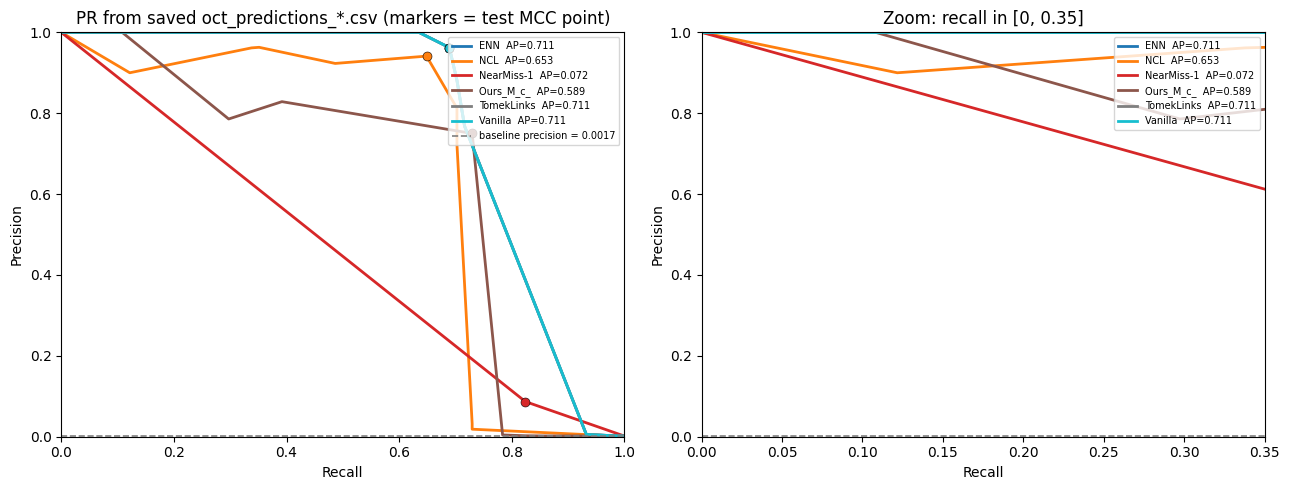

Saved figure: ./uci_competing_methods_results/pr_curves_from_saved_oct_predictions.png


In [3]:
import os
import sys
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import (
    precision_recall_curve,
    average_precision_score,
    precision_score,
    recall_score,
)

RESULTS_DIR = "./uci_competing_methods_results"
TRAIN_TEST_SEED = 123
TARGET_COL = "target"

repo_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if repo_root not in sys.path:
    sys.path.insert(0, repo_root)
from utils_fraud import prepare_dataset_for_kcenter, setup_feature_columns, create_train_test_split
from public.model_IAI import best_mcc_threshold

df_raw = pd.read_csv("creditcard.csv")
X_raw = df_raw.drop(columns=["Class"])
y_raw = df_raw["Class"]
df = prepare_dataset_for_kcenter(X_raw, y_raw, dataset_name="creditcard_fraud")
df, feature_cols, _, _, _ = setup_feature_columns(
    df, target_col=TARGET_COL, drop_time=False, log1p_amount=False
)
_, _, test_pd = create_train_test_split(df, target_col=TARGET_COL, random_state=TRAIN_TEST_SEED)
y_true = test_pd[TARGET_COL].astype(int).values

pattern = os.path.join(RESULTS_DIR, "*", "predictions", "oct_predictions_*.csv")
paths = sorted(glob.glob(pattern))
if not paths:
    raise FileNotFoundError(f"No files matching {pattern}. Run the benchmark cell first.")

prevalence = float(np.mean(y_true))
print(f"Test positives: {y_true.sum():,} / {len(y_true):,}  (prevalence = {prevalence:.5f})")

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
cmap = plt.cm.tab10(np.linspace(0, 0.9, max(len(paths), 1)))

for i, pth in enumerate(paths):
    tag = os.path.basename(pth).replace("oct_predictions_", "").replace(".csv", "")
    pred = pd.read_csv(pth)
    if "predicted_proba" not in pred.columns:
        print(f"skip {pth}: no predicted_proba")
        continue
    scores = pred["predicted_proba"].astype(float).values
    if len(scores) != len(y_true):
        print(f"skip {tag}: len(scores)={len(scores)} != len(y_true)={len(y_true)}")
        continue

    ap = average_precision_score(y_true, scores)
    precision, recall, _ = precision_recall_curve(y_true, scores)
    axes[0].plot(recall, precision, lw=2, color=cmap[i % 10], label=f"{tag}  AP={ap:.3f}")

    mcc = best_mcc_threshold(y_true, scores)
    y_hat = mcc["y_pred"]
    rp = recall_score(y_true, y_hat, zero_division=0)
    pp = precision_score(y_true, y_hat, zero_division=0)
    axes[0].scatter([rp], [pp], s=42, color=cmap[i % 10], edgecolors="k", linewidths=0.4, zorder=5)

axes[0].axhline(prevalence, color="gray", ls="--", lw=1.2, label=f"baseline precision = {prevalence:.4f}")
axes[0].set_xlabel("Recall")
axes[0].set_ylabel("Precision")
axes[0].set_title("PR from saved oct_predictions_*.csv (markers = test MCC point)")
axes[0].set_xlim(0, 1)
axes[0].set_ylim(0, 1)
axes[0].legend(loc="upper right", fontsize=7)

for i, pth in enumerate(paths):
    pred = pd.read_csv(pth)
    if "predicted_proba" not in pred.columns:
        continue
    scores = pred["predicted_proba"].astype(float).values
    if len(scores) != len(y_true):
        continue
    ap = average_precision_score(y_true, scores)
    precision, recall, _ = precision_recall_curve(y_true, scores)
    tag = os.path.basename(pth).replace("oct_predictions_", "").replace(".csv", "")
    axes[1].plot(recall, precision, lw=2, color=cmap[i % 10], label=f"{tag}  AP={ap:.3f}")

axes[1].axhline(prevalence, color="gray", ls="--", lw=1.2)
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")
axes[1].set_title("Zoom: recall in [0, 0.35]")
axes[1].set_xlim(0, 0.35)
axes[1].set_ylim(0, 1)
axes[1].legend(loc="upper right", fontsize=7)

plt.tight_layout()
out_png = os.path.join(RESULTS_DIR, "pr_curves_from_saved_oct_predictions.png")
plt.savefig(out_png, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved figure: {out_png}")
